# Analiza dialogowa scenariusza: kto mówi, ile i czyim głosem

## Wersja studencka — moduł 2: GŁOS I PŁEĆ

W poprzednim module zbudowałeś *sieć współwystąpień* — pokazała, kto z kim **pojawia się** w scenach. Ale scenariusz wie znacznie więcej: wie, **kto mówi**, **ile mówi** i **czyimi ustami** prowadzona jest narracja. Ten notatnik wydobywa z tego samego scenariusza warstwę **dialogów**.

Efektem końcowym będzie:
1. odzyskanie czystego tekstu scenariusza (jak w module sieciowym),
2. wydzielenie scen i przypisanie do nich kwestii dialogowych,
3. tabela: która postać wypowiada które kwestie i ile słów,
4. otagowanie postaci płcią,
5. wykres udziału w dialogu z podziałem na płeć,
6. zapis plików `dialogi.csv` i `postacie.csv` do dalszej analizy emocji.

Tak jak poprzednio: nie piszesz kodu samodzielnie. Każdy krok to prompt, który przekazujesz modelowi AI, a wygenerowany kod wklejasz do pustej komórki pod spodem.

## Jak pracować z tym notatnikiem

1. Zmień adres scenariusza w komórce parametru (najlepiej ten sam film, co w module sieciowym).
2. Skopiuj prompt z bieżącego kroku do modelu AI.
3. Wklej otrzymany kod do pustej komórki pod promptem.
4. Uruchom kod i porównaj rezultat z sekcją **Po uruchomieniu powinieneś zobaczyć**.
5. Jeśli wynik nie zgadza się z opisem, popraw tylko bieżący krok.
6. Dopiero po uzyskaniu poprawnego wyniku przejdź dalej.

Każdy krok prosi model o konkretną nazwę zmiennej dla wyniku (np. `tekst_scenariusza`, `dialogi`, `ranking`). Od tych nazw zależy działanie bramek kontrolnych w notatniku — szczegóły w komórce *Anatomia promptu* poniżej.

**O komórkach `moj_prompt = …`:** dwie takie komórki pojawią się w tym notatniku (Krok 2C i Etap 5). To ćwiczenia z samodzielną decyzją: edytuj zmienną, uruchom (komórka sprawdzi i wypisze gotowy prompt), skopiuj wynik do asystenta AI. W NB2 i NB3 ten wzorzec będzie normą.

## Anatomia promptu — jak czytać instrukcje w tym notatniku

Każdy krok zawiera gotowy prompt do przekazania modelowi AI. Zanim go użyjesz, przeczytaj go uważnie — wszystkie prompty mają ten sam szkielet **7 sekcji**:

| Sekcja | Co zawiera | Dlaczego ważna |
|---|---|---|
| **Kontekst** | Sytuacja, z której startuje model | Model nie widzi historii Twoich komórek — musi wiedzieć, skąd pochodzi kod i dane |
| **Wejście** | Co dokładnie przekazujesz | Określa, co model ma „zobaczyć" |
| **Zadanie** | Precyzyjna lista czynności | Serce promptu — im konkretniej, tym lepszy kod |
| **Pokaż wynik** | Jak powinna wyglądać odpowiedź | Kontrolujesz kształt wyjścia |
| **Warunek poprawności** | Jak odróżnić dobry wynik od błędnego | Twoja lista kontrolna po uruchomieniu |
| **Jeśli wystąpi błąd** | Co zrobić, gdy coś pójdzie nie tak | Plan B wbudowany w prompt |
| **Nie rób jeszcze** | Co ma poczekać na następny krok | Zapobiega „wybieganiu" modelu do przodu |

> **Twoje zadanie w tym module:** naucz się **czytać** te prompty i rozumieć, dlaczego każda sekcja jest tam, gdzie jest. W NB2 będziesz je **uzupełniać** w komórce kodu `moj_prompt`, a w NB3 — **pisać od zera** w pustym szkielecie. Za każdym razem komórka sprawdzi, czy prompt jest gotowy do skopiowania.

> **O nazwach zmiennych:** każdy prompt prosi model o konkretną nazwę zmiennej (np. `tekst_scenariusza`). To nieprzypadkowe — precyzja w sekcji „Zadanie" to cecha dobrego promptu, a od tych nazw zależy działanie bramek w notatniku.

## Parametr startowy

To jedyna komórka, którą zmieniasz ręcznie. Wybierz adres strony scenariusza z IMSDb — najlepiej ten sam film, dla którego budowałeś sieć w module pierwszym.

In [5]:
adres_scenariusza = "https://imsdb.com/scripts/Avengers-Endgame.html$0"

---
## Etap 1/6 — Odzyskanie czystego tekstu scenariusza

Zaczynamy od tego samego punktu, co moduł sieciowy: pobieramy stronę i wydobywamy z niej sam tekst scenariusza.

In [6]:
# === ETAP 1/6 · ODZYSKANIE TEKSTU SCENARIUSZA ===
assert 'adres_scenariusza' in dir() and adres_scenariusza.startswith("http"), \
    "⛔ Ustaw adres_scenariusza w komórce parametru powyżej."
print(f"📍 Etap 1/6 · Odzyskanie tekstu scenariusza z:\n    {adres_scenariusza}")

📍 Etap 1/6 · Odzyskanie tekstu scenariusza z:
    https://imsdb.com/scripts/Avengers-Endgame.html$0


### Krok 1A. Pobranie strony i wydobycie tekstu scenariusza

#### Cel i sens analityczny

Cała dalsza analiza opiera się na czystym tekście scenariusza. Musimy odzyskać go z podanego adresu — bez menu, stopek i elementów witryny.

#### Prompt dla modelu

```text
Kontekst:
Pracujesz na stronie scenariusza filmowego z serwisu IMSDb. Strona zawiera menu, linki i elementy witryny, których nie chcemy.

Wejście:
Adres scenariusza zapisany w zmiennej `adres_scenariusza`.

Zadanie:
Pobierz stronę i wydobądź z niej wyłącznie właściwy tekst scenariusza (dialogi i didaskalia), odrzucając nawigację, nagłówki i stopki witryny. Zachowaj oczyszczony tekst w zmiennej o nazwie `tekst_scenariusza`.

Pokaż wynik:
- komunikat, czy pobranie i oczyszczenie się udało,
- liczbę znaków i linii oczyszczonego tekstu,
- pierwsze 15 niepustych linii.

Warunek poprawności:
Podgląd powinien przypominać zapis scenariusza (nagłówki scen, nazwy postaci, kwestie), a nie elementy strony. Tekst nie może być pusty.

Jeśli wystąpi błąd:
Wyjaśnij, czy problem dotyczy adresu, połączenia, czy nieznalezienia bloku z tekstem.

Nie rób jeszcze:
Nie wykrywaj scen ani postaci, nie analizuj dialogów.
```

In [ ]:
# tu wklej kod wygenerowany przez model

#### Po uruchomieniu powinieneś zobaczyć

- Potwierdzenie, że tekst został pobrany i oczyszczony.
- Liczbę znaków i linii oraz kilkanaście pierwszych linii wyglądających jak scenariusz.
- Brak widocznego menu, stopki i innych elementów witryny.

---
## Etap 2/6 — Od tekstu do kwestii dialogowych

Zamieniamy ciągły tekst w **tabelę kwestii** — kto, w której scenie, co powiedział. To będzie surowiec do liczenia mowy i emocji.

In [11]:
# === ETAP 2/6 · OD TEKSTU DO KWESTII DIALOGOWYCH ===
assert 'tekst_scenariusza' in dir() and isinstance(tekst_scenariusza, str) and len(tekst_scenariusza) > 100, \
    "⛔ Najpierw uruchom Etap 1 — brak zmiennej `tekst_scenariusza`."
print(f"📍 Etap 2/6 · Wykrywanie scen i kwestii. "
      f"Wejście: `tekst_scenariusza` ({len(tekst_scenariusza):,} znaków).")

📍 Etap 2/6 · Wykrywanie scen i kwestii. Wejście: `tekst_scenariusza` (122,719 znaków).


### Krok 2A. Wykrycie granic scen

#### Cel i sens analityczny

Chcemy przypisać każdą kwestię do sceny, w której pada — to pozwoli śledzić emocje w czasie. Najpierw odnajdujemy granice scen.

#### Prompt dla modelu

```text
Kontekst:
W scenariuszach nowe sceny otwierają nagłówki opisujące miejsce i czas akcji, często zaczynające się od skrótów oznaczających wnętrze lub plener.

Wejście:
Oczyszczony tekst scenariusza w zmiennej `tekst_scenariusza`.

Zadanie:
Wykryj granice scen i zbuduj uporządkowaną listę scen z numerami i nagłówkami. Zachowaj wynik w zmiennej o nazwie `sceny`, tak aby w kolejnym kroku dało się przypisać każdą kwestię do numeru sceny.

Pokaż wynik:
- łączną liczbę rozpoznanych scen,
- pierwszych 8 rekordów w formie `numer sceny | nagłówek sceny`.

Warunek poprawności:
Nagłówki powinny wyglądać jak opisy miejsca i czasu, a nie jak dialog.

Jeśli wystąpi błąd:
Wyjaśnij, że nie udało się znaleźć wyraźnych granic scen albo że nagłówki są niejednoznaczne.

Nie rób jeszcze:
Nie przypisuj kwestii do scen ani postaci.
```

In [ ]:
# tu wklej kod wygenerowany przez model

In [25]:
import re

sceny = []
# Standard scene header patterns in scripts (INT. or EXT.)
scene_pattern = re.compile(r'^(?:INT\.|EXT\.|INT/EXT\.|EXT/INT\.)\s+.*', re.IGNORECASE)

lines = tekst_scenariusza.splitlines()
scene_count = 0

for line in lines:
    clean_line = line.strip()
    if scene_pattern.match(clean_line):
        scene_count += 1
        sceny.append({
            'numer_sceny': scene_count,
            'naglowek': clean_line
        })

if sceny:
    print(f"✅ Łączna liczba rozpoznanych scen: {len(sceny)}")
    print("\n--- Pierwszych 8 rekordów ---")
    print("numer sceny | nagłówek sceny")
    print("-" * 40)
    for s in sceny[:8]:
        print(f"{s['numer_sceny']} | {s['naglowek']}")
else:
    print("❌ Nie udało się znaleźć wyraźnych granic scen (brak nagłówków INT./EXT.).")

✅ Łączna liczba rozpoznanych scen: 148

--- Pierwszych 8 rekordów ---
numer sceny | nagłówek sceny
----------------------------------------
1 | EXT. BARTON HOME - DAY
2 | EXT. SPACE - NIGHT
3 | INT. BENATAR, GALLEY - NIGHT
4 | INT. BENATAR, FLIGHT DECK - NIGHT
5 | EXT. SPACE - NIGHT
6 | INT. BENATAR, GALLEY - FLASHBACK
7 | INT. BENATAR, GALLEY - FLASHBACK
8 | EXT. SPACE - NIGHT


#### Po uruchomieniu powinieneś zobaczyć

- Liczbę scen rozpoznanych w całym tekście.
- Listę pierwszych nagłówków scen.

### Krok 2B. Wydobycie kwestii dialogowych

#### Cel i sens analityczny

W zapisie scenariusza kwestia dialogowa ma stały wzór: **nazwa postaci** (wielkimi literami, wcięta), a pod nią **tekst wypowiedzi**. Wydobędziemy te pary i przypiszemy je do scen.

#### Prompt dla modelu

```text
Kontekst:
W scenariuszu kwestia dialogowa wygląda tak: w osobnej linii nazwa postaci zapisana wielkimi literami i wcięta, a bezpośrednio pod nią jedna lub kilka linii wypowiedzi. Nazwa może mieć dopisek w nawiasie (wskazówka aktorska), który należy usunąć. Linie pisane od lewego marginesu to zwykle didaskalia.

Wejście:
Tekst scenariusza w `tekst_scenariusza` i lista scen w `sceny`.

Zadanie:
Przejdź przez tekst i wydobądź wszystkie kwestie dialogowe. Dla każdej kwestii zapisz: numer sceny, oczyszczoną nazwę postaci, treść wypowiedzi i liczbę słów. Nazwy postaci oczyść (wielkie litery, bez dopisków w nawiasach). Pomiń didaskalia, nagłówki scen i przejścia montażowe. Zachowaj wynik jako tabelę o nazwie `dialogi`.

Pokaż wynik:
- łączną liczbę wydobytych kwestii,
- liczbę unikalnych postaci mówiących,
- próbkę 15 wierszy: `numer sceny | postać | liczba słów | początek kwestii`.

Warunek poprawności:
W kolumnie postaci powinny dominować imiona lub nazwy, a treść kwestii powinna wyglądać jak wypowiedź — nie jak opis kamery.

Jeśli wystąpi błąd:
Pokaż kilka problematycznych fragmentów i wyjaśnij przyczynę.

Nie rób jeszcze:
Nie licz sumarycznej mowy postaci ani nie analizuj płci.
```

In [ ]:
# tu wklej kod wygenerowany przez model

In [31]:
import pandas as pd
import re

dialogi_data = []
current_scene_idx = 0
lines = tekst_scenariusza.splitlines()

# Regex patterns for script elements
scene_pattern = re.compile(r'^(?:INT\.|EXT\.|INT/EXT\.|EXT/INT\.)\s+.*', re.IGNORECASE)
# Matches uppercase lines (character names), potentially with parentheticals
character_pattern = re.compile(r'^[A-Z\s]{2,}(?:\s\(.*\))?$')
# Common transitions to ignore
transitions = {'CUT TO:', 'FADE IN:', 'FADE OUT:', 'FADE TO BLACK.', 'DISSOLVE TO:', 'SMASH CUT TO:', 'MATCH CUT TO:'}

i = 0
while i < len(lines):
    line = lines[i].strip()

    # Update scene context
    if scene_pattern.match(line):
        for s in sceny:
            if s['naglowek'] == line:
                current_scene_idx = s['numer_sceny']
                break
        i += 1
        continue

    # Identify character and subsequent dialogue
    if character_pattern.match(line) and line not in transitions and not scene_pattern.match(line):
        # Strip parentheticals like (O.S.) or (CONT'D)
        character_name = re.sub(r'\s\(.*\)', '', line).strip()

        speech_lines = []
        i += 1
        while i < len(lines):
            next_line = lines[i].strip()
            # Stop if the line is empty, or starts a new character/scene
            if not next_line or character_pattern.match(next_line) or scene_pattern.match(next_line):
                break
            speech_lines.append(next_line)
            i += 1

        if speech_lines:
            full_text = " ".join(speech_lines)
            dialogi_data.append({
                'numer_sceny': current_scene_idx,
                'postac': character_name,
                'tresc_kwestii': full_text,
                'liczba_slow': len(full_text.split())
            })
        continue

    i += 1

# Create the DataFrame
dialogi = pd.DataFrame(dialogi_data)

if not dialogi.empty:
    print(f"✅ Łączna liczba wydobytych kwestii: {len(dialogi)}")
    print(f"Liczba unikalnych postaci mówiących: {dialogi['postac'].nunique()}")
    print("\n--- Próbka 15 wierszy ---")

    # Formatting sample for display
    sample_display = dialogi.copy().head(15)
    sample_display['poczatek_kwestii'] = sample_display['tresc_kwestii'].apply(lambda x: x[:50] + "..." if len(x) > 50 else x)
    display(sample_display[['numer_sceny', 'postac', 'liczba_slow', 'poczatek_kwestii']])
else:
    print("❌ Nie udało się wydobyć kwestii dialogowych. Sprawdź formatowanie tekstu.")

✅ Łączna liczba wydobytych kwestii: 1042
Liczba unikalnych postaci mówiących: 54

--- Próbka 15 wierszy ---


,numer_sceny,postac,liczba_slow,poczatek_kwestii
0,1,CLINT BARTON,32,"Okay, you see where you're going? Let's work o..."
1,1,CLINT BARTON,6,"Okay, good...tip down...bow arm out...three fi..."
2,1,LILA BARTON,2,Why three?
3,1,CLINT BARTON,8,`Cause two's not enough and four's too much-
4,1,LAURA BARTON,29,"You guys want mustard or mayo, or both? CLINT ..."
5,1,LILA BARTON,7,Who puts mayo on a hot dog?
6,1,CLINT BARTON,22,"We'll both have mustard, hon! (to Lila) Okay. ..."
7,1,CLINT BARTON,7,"Good job, Hawkeye. Go get your arrow."
8,1,LAURA BARTON,5,Enough murder practice! Soup's on!
9,1,CLINT BARTON,32,"One sec, babe. Be right there! We're gonna kil..."


#### Po uruchomieniu powinieneś zobaczyć

- Łączną liczbę kwestii i liczbę unikalnych postaci mówiących.
- Próbkę wierszy: scena, postać, liczba słów, początek wypowiedzi.
- Wypowiedzi wyglądające jak dialog — bez didaskaliów i nagłówków.

### Krok 2C. Przegląd i oczyszczenie listy postaci

#### Cel i sens analityczny

Parsery scenariuszowe często mylą wskazówki montażowe z dialogami: "FADE TO BLACK", "CONTINUED", "INTERCUT WITH" mogą trafić do tabeli `dialogi` jako nazwy postaci. Jeśli to nastąpi, fałszywe wpisy zawyżą liczbę unikalnych postaci i zepsują rankingi i wykres płci.

Ten krok to punkt kontroli jakości — uruchom komórkę poniżej, przejrzyj listę i usuń fałszywe postacie, jeśli się pojawiły.

> **Ten krok jest opcjonalny.** Jeśli lista wygląda poprawnie (same imiona i nazwy postaci), możesz go pominąć.

In [24]:
# PRZEGLĄD — uruchom i sprawdź listę unikalnych wpisów w kolumnie postaci
assert 'dialogi' in dir(), "⛔ Najpierw uruchom Krok 2B — brak tabeli `dialogi`."
print(f"📋 `dialogi`: {len(dialogi):,} kwestii | kolumny: {list(dialogi.columns)}\n")
# Heurystycznie znajdź kolumnę z nazwami postaci
_kol = next(
    (c for c in dialogi.columns
     if any(k in c.lower() for k in
            ('postac', 'postać', 'character', 'speaker', 'char', 'person'))),
    None
)
if _kol is None:
    _str_cols = [c for c in dialogi.columns if str(dialogi[c].dtype) == 'object']
    _kol = max(_str_cols, key=lambda c: dialogi[c].nunique()) if _str_cols else dialogi.columns[1]
    print(f"⚠️  Nie znaleziono kolumny 'postać' po nazwie — próbuję '{_kol}'.\n")
# Przykładowe wiersze — żeby zobaczyć jak wyglądają dane
print("── Przykładowe wiersze (pierwsze 15) ──────────────────────────")
print(dialogi.head(15).to_string(index=False))
# Unikalne nazwy postaci pod spodem
print(f"\n── Unikalne nazwy postaci w kolumnie '{_kol}' ({dialogi[_kol].nunique()} unikalnych) ──")
print(dialogi[_kol].value_counts().to_string())

📋 `dialogi`: 1,042 kwestii | kolumny: ['numer_sceny', 'postac', 'tresc_kwestii', 'liczba_slow']

── Przykładowe wiersze (pierwsze 15) ──────────────────────────
 numer_sceny       postac                                                                                                                                                                                                     tresc_kwestii  liczba_slow
           1 CLINT BARTON                                        Okay, you see where you're going? Let's work on how to get there. Pan up to find...CLINT BARTON, with his daughter, LILA, coaching her as she notches an arrow in her bow.           32
           1 CLINT BARTON                                                                                                                                                              Okay, good...tip down...bow arm out...three fingers-            6
           1  LILA BARTON                                                                   

#### Twoja kolej: sprawdź i dostosuj prompt

Przejrzyj listę powyżej. Jeśli widzisz fałszywe postacie (stage directions, przejścia montażowe, adnotacje techniczne) — wpisz je w lukę `[WPISZ: …]` w komórce kodu poniżej i uruchom.

> **Jeśli lista wygląda poprawnie**, wpisz w lukę: `(brak)` — prompt poinformuje model, że nic nie trzeba usuwać, a `dialogi` zostanie bez zmian.

In [39]:
# TWOJA KOLEJ: wpisz fałszywe postacie znalezione w Twoim filmie, potem uruchom.
moj_prompt_oczyszczanie = """
Kontekst:
Masz tabelę kwestii dialogowych `dialogi`. Podczas wydobywania kwestii parser mógł
omyłkowo sklasyfikować wskazówki montażowe lub didaskalia jako nazwy postaci.

Wejście:
Tabela `dialogi` (kolumny widoczne po uruchomieniu komórki przeglądu powyżej).

Zadanie:
Oczyść tabelę. Usuń wiersze, w których kolumna postaci zawiera wpis z poniższej
listy typowych fałszywych postaci:
"WATER DRIPS FROM A HOLE IN THE ROOF OF AN ACCESS", "EVERYONE EYES THE TANGLE OF LINES CONNECTING SIX STONES TO",
"THANOS SNATCHES TONY BY THE ANKLE AND USES HIM AS A SHIELD"

Dodatkowo usuń wpisy specyficzne dla mojego filmu:
WATER DRIPS FROM A HOLE IN THE ROOF OF AN ACCESS, EVERYONE EYES THE TANGLE OF LINES CONNECTING SIX STONES TO, THANOS SNATCHES TONY BY THE ANKLE AND USES HIM AS A SHIELD

Jeśli żaden wpis nie wymaga usunięcia — wypisz potwierdzenie i nie modyfikuj tabeli.
Zachowaj wynik (po oczyszczeniu lub bez zmian) jako zmienną `dialogi`.

Pokaż wynik:
- ile wierszy usunięto (0 to poprawny wynik),
- jakie nazwy były w usuniętych wierszach,
- nową łączną liczbę kwestii i unikalnych postaci.

Warunek poprawności:
Lista postaci nie powinna zawierać słów typowych dla notacji filmowej.
Jeżeli "V.O." lub "O.S." pojawia się jako samodzielny wpis (bez imienia przed), też należy do usunięcia.

Jeżeli wystąpi błąd:
Wyjaśnij, której kolumny nie udało się znaleźć w `dialogi`.

Nie rób jeszcze:
Nie przeliczaj sumarycznej mowy ani nie rysuj wykresów.
"""

assert "[WPISZ" not in moj_prompt_oczyszczanie, \
    "⛔ Wypełnij lukę — wpisz fałszywe postacie lub (brak) jeśli lista jest czysta."

print("✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:\n")
print(moj_prompt_oczyszczanie)

✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:


Kontekst:
Masz tabelę kwestii dialogowych `dialogi`. Podczas wydobywania kwestii parser mógł
omyłkowo sklasyfikować wskazówki montażowe lub didaskalia jako nazwy postaci.

Wejście:
Tabela `dialogi` (kolumny widoczne po uruchomieniu komórki przeglądu powyżej).

Zadanie:
Oczyść tabelę. Usuń wiersze, w których kolumna postaci zawiera wpis z poniższej
listy typowych fałszywych postaci:
"WATER DRIPS FROM A HOLE IN THE ROOF OF AN ACCESS", "EVERYONE EYES THE TANGLE OF LINES CONNECTING SIX STONES TO",
"THANOS SNATCHES TONY BY THE ANKLE AND USES HIM AS A SHIELD"

Dodatkowo usuń wpisy specyficzne dla mojego filmu:
WATER DRIPS FROM A HOLE IN THE ROOF OF AN ACCESS, EVERYONE EYES THE TANGLE OF LINES CONNECTING SIX STONES TO, THANOS SNATCHES TONY BY THE ANKLE AND USES HIM AS A SHIELD

Jeśli żaden wpis nie wymaga usunięcia — wypisz potwierdzenie i nie modyfikuj tabeli.
Zachowaj wynik (po oczyszczeniu lub bez zmian) jako zmienną `dialogi`.

Po

In [ ]:
# tu wklej kod wygenerowany przez model

In [41]:
# List of false character names to remove based on the previous step
false_characters = [
    "WATER DRIPS FROM A HOLE IN THE ROOF OF AN ACCESS",
    "EVERYONE EYES THE TANGLE OF LINES CONNECTING SIX STONES TO",
    "THANOS SNATCHES TONY BY THE ANKLE AND USES HIM AS A SHIELD"
]

# Filter out rows where the 'postac' column matches these false entries
if 'dialogi' in locals() or 'dialogi' in globals():
    initial_count = len(dialogi)
    removed_names = dialogi[dialogi['postac'].isin(false_characters)]['postac'].unique().tolist()

    dialogi = dialogi[~dialogi['postac'].isin(false_characters)].copy()

    # Also remove generic technical markers if they appear as standalone names
    technical_markers = ["V.O.", "O.S.", "CONT'D"]
    dialogi = dialogi[~dialogi['postac'].isin(technical_markers)].copy()

    final_count = len(dialogi)
    rows_removed = initial_count - final_count

    print(f"✅ Oczyszczanie zakończone.")
    print(f"- Usunięto wierszy: {rows_removed}")
    if removed_names:
        print(f"- Usunięte nazwy: {', '.join(removed_names)}")
    print(f"- Nowa łączna liczba kwestii: {final_count}")
    print(f"- Nowa liczba unikalnych postaci: {dialogi['postac'].nunique()}")
else:
    print("❌ Błąd: Nie znaleziono tabeli `dialogi`. Uruchom najpierw Krok 2B.")

✅ Oczyszczanie zakończone.
- Usunięto wierszy: 0
- Nowa łączna liczba kwestii: 1039
- Nowa liczba unikalnych postaci: 51


#### Po uruchomieniu powinieneś zobaczyć

- Informację o liczbie usuniętych wierszy (0 = tabela była czysta).
- Listę usuniętych nazw (jeśli były).
- Zaktualizowaną liczbę kwestii i unikalnych postaci w `dialogi`.

> **Jeśli coś zostało usunięte przez pomyłkę** (np. postać o imieniu zbliżonym do stage direction), cofnij to: poproś model o odtworzenie konkretnych wierszy z `tekst_scenariusza` lub uruchom Krok 2B ponownie z prośbą o ostrożniejsze filtrowanie.

---
## Etap 3/6 — Kto mówi najwięcej?

Mamy wszystkie kwestie. Teraz liczymy, ile mowy przypada na każdą postać — pierwsza, prosta miara „głosu" w narracji.

In [50]:
# === ETAP 3/6 · KTO MÓWI NAJWIĘCEJ? ===
assert 'dialogi' in dir(), "⛔ Najpierw uruchom Etap 2 — brak tabeli `dialogi`."
print(f"📍 Etap 3/6 · Ranking mowy. Wejście: `dialogi` ({len(dialogi):,} kwestii).")

📍 Etap 3/6 · Ranking mowy. Wejście: `dialogi` (1,039 kwestii).


In [43]:
# HIPOTEZA — wpisz ZANIM uruchomisz krok poniżej
# Która postać Twoim zdaniem mówi w tym filmie najwięcej? Dlaczego?
moja_hipoteza_3 = "Tony — bo pojawia się w połowie scen"   # np. "Tony — bo pojawia się w połowie scen"
assert moja_hipoteza_3.strip(), \
    "⛔ Najpierw postaw hipotezę — co myślisz, zanim zobaczysz dane?"
print("✏️  Hipoteza zapisana. Teraz wygeneruj kod z promptu i sprawdź, co wyjdzie.")

✏️  Hipoteza zapisana. Teraz wygeneruj kod z promptu i sprawdź, co wyjdzie.


### Krok 3A. Ranking postaci według ilości mowy

#### Cel i sens analityczny

Liczba wypowiedzianych słów pokazuje, czyimi ustami prowadzona jest opowieść. To inna miara niż liczba scen z modułu sieciowego — można być w wielu scenach i milczeć, albo zdominować dialog w niewielu.

#### Prompt dla modelu

```text
Kontekst:
Masz tabelę kwestii dialogowych w zmiennej `dialogi` z kolumną postaci i kolumną liczby słów.

Wejście:
Tabela `dialogi` z poprzedniego kroku.

Zadanie:
Dla każdej postaci policz: łączną liczbę słów, liczbę kwestii i liczbę różnych scen, w których zabiera głos. Posortuj malejąco według liczby słów. Zachowaj wynik jako tabelę o nazwie `ranking`.

Pokaż wynik:
- łączną liczbę postaci mówiących,
- tabelę 20 najwięcej mówiących postaci: `postać | liczba słów | liczba kwestii | liczba scen`.

Warunek poprawności:
Suma słów wszystkich postaci powinna odpowiadać łącznej liczbie słów we wszystkich kwestiach.

Jeśli wystąpi błąd:
Wyświetl informację, czy tabela kwestii jest pusta albo czy liczby słów się nie sumują.

Nie rób jeszcze:
Nie rysuj wykresu i nie analizuj płci.
```

In [62]:
import pandas as pd

# Grupowanie według postaci i agregacja danych
ranking = dialogi.groupby('postac').agg(
    liczba_slow=('liczba_slow', 'sum'),
    liczba_kwestii=('postac', 'count'),
    liczba_scen=('numer_sceny', 'nunique')
).sort_values(by='liczba_slow', ascending=False).reset_index()

# Weryfikacja poprawności
total_words_dialogi = dialogi['liczba_slow'].sum()
total_words_ranking = ranking['liczba_slow'].sum()

if not ranking.empty and total_words_dialogi == total_words_ranking:
    print(f"✅ Ranking wygenerowany pomyślnie.")
    print(f"Liczba mówiących postaci: {len(ranking)}")
    print("\n--- Top 20 postaci według liczby słów ---")
    display(ranking.head(20))
else:
    print("⛔ Błąd: Suma słów w rankingu nie zgadza się z tabelą dialogi.")

✅ Ranking wygenerowany pomyślnie.
Liczba mówiących postaci: 51

--- Top 20 postaci według liczby słów ---


,postac,liczba_slow,liczba_kwestii,liczba_scen
0,TONY,2528,150,32
1,STEVE,1528,109,31
2,SMART HULK,1190,77,14
3,SCOTT LANG,1029,73,22
4,NATASHA,917,75,19
5,THOR,888,64,9
6,CLINT BARTON,787,52,15
7,RHODEY,777,48,16
8,THANOS,693,43,6
9,ROCKET,690,54,14


#### Po uruchomieniu powinieneś zobaczyć

- Tabelę rankingową postaci posortowaną malejąco wg liczby słów.
- Dla każdej postaci trzy liczby: słowa, kwestie, sceny.

In [52]:
# CHECKPOINT — uzupełnij na podstawie tabeli powyżej
postac_top_3 = "Tony"  # wpisz DOKŁADNĄ nazwę postaci z 1. miejsca rankingu (jak w tabeli)
assert postac_top_3.strip(), "⛔ Spójrz na tabelę i wpisz nazwę postaci z 1. miejsca."
print(f"📊 Checkpoint: '{postac_top_3}' mówi najwięcej w Twoim filmie.")
h = moja_hipoteza_3.upper()
p = postac_top_3.strip().upper()
if p in h:
    print("✅ Zgadza się z Twoją hipotezą!")
else:
    print(f"🤔 Dane wskazują na '{postac_top_3}', hipoteza mówiła o czymś innym — "
          "zastanów się, dlaczego — to ciekawy materiał interpretacyjny!")

📊 Checkpoint: 'Tony' mówi najwięcej w Twoim filmie.
✅ Zgadza się z Twoją hipotezą!


#### Pytanie interpretacyjne

Porównaj ten ranking z rankingiem liczby scen z modułu sieciowego. Czy najczęściej *obecne* postacie to te same, co najwięcej *mówiące*? Czy jest ktoś, kto „dużo znaczy w sieci, ale mało mówi" — albo odwrotnie?

---
## Etap 4/6 — Płeć postaci

Żeby zapytać o reprezentację — kto ma głos w tym filmie — potrzebujemy przypisać postaciom płeć. Zrobi to model, a Ty zweryfikujesz wynik.

In [53]:
# === ETAP 4/6 · PŁEĆ POSTACI ===
assert 'ranking' in dir(), "⛔ Najpierw uruchom Etap 3 — brak tabeli `ranking`."
print(f"📍 Etap 4/6 · Tagowanie płci. Wejście: `ranking` ({len(ranking)} postaci).")

📍 Etap 4/6 · Tagowanie płci. Wejście: `ranking` (51 postaci).


### Krok 4A. Otagowanie postaci płcią

#### Cel i sens analityczny

Płeć postaci to *atrybut*, który pozwoli spojrzeć na rozkład mowy pod kątem reprezentacji. To zarazem moment krytyczny: płeć przypisana automatycznie bywa uproszczeniem — wynik trzeba przejrzeć ręcznie.

**Podpowiedź:** ten krok różni się od poprzednich. Przekaż modelowi **listę postaci z rankingu** — potrzebuje nazw, żeby przypisać płeć, korzystając z wiedzy o filmie.

#### Prompt dla modelu

```text
Kontekst:
Masz listę postaci mówiących z konkretnego filmu. Chcesz przypisać każdej z nich płeć.

Wejście:
Lista postaci z rankingu `ranking` (wklejam ją poniżej promptu).

Zadanie:
Dla każdej postaci przypisz płeć: "K" (kobieta), "M" (mężczyzna) albo "?" (niejednoznaczna, zbiorowa lub nieznana). Zachowaj wynik jako słownik Pythona o nazwie `plec` (mapujący postać → płeć), tak żeby dało się go poprawić jedną linijką kodu.

Pokaż wynik:
- słownik `plec` dla wszystkich postaci z listy,
- podsumowanie: ile postaci oznaczono jako K, M oraz ?.

Warunek poprawności:
Każda postać ma dokładnie jedną wartość: K, M lub ?. Postacie zbiorowe i niejednoznaczne → ?.

Jeśli wystąpi błąd:
Wskaż postacie, których płci nie da się rozstrzygnąć, i wyjaśnij dlaczego.

Nie rób jeszcze:
Nie rysuj wykresu.
```

In [63]:
import pandas as pd

# Pobieramy listę postaci z rankingu
postacie_lista = ranking['postac'].tolist()

# Słownik płci dla postaci z Avengers: Endgame
plec = {
    'TONY': 'M', 'STEVE': 'M', 'SMART HULK': 'M', 'THOR': 'M', 'NEBULA': 'K',
    'NATASHA': 'K', 'SCOTT': 'M', 'RHODEY': 'M', 'CLINT': 'M', 'ROCKET': 'M',
    'THANOS': 'M', 'GAMORA': 'K', 'VALKYRIE': 'K', 'CAROL': 'K', 'FRIGGA': 'K',
    'OKOYE': 'K', 'ALEXANDER PIERCE': 'M', 'SITWELL': 'M', 'RUMELOW': 'M',
    'ANCIENT ONE': 'K', 'PEPPER': 'K', 'FRIDAY': 'K', 'JARVIS': 'M', 'MORGAN': 'K',
    'HOWARD': 'M', 'KORG': 'M', 'MIEK': 'M', 'DRAX': 'M', 'MANTIS': 'K',
    'GROOT': 'M', 'PETER PARKER': 'M', 'SAM': 'M', 'BUCKY': 'M', 'WANDA': 'K',
    'T\'CHALLA': 'M', 'SHURI': 'K', 'HOPE': 'K', 'PETER QUILL': 'M',
    'CLINT BARTON': 'M', 'LAURA BARTON': 'K', 'LILA BARTON': 'K', 'COOPER': 'M',
    'NATHANIEL': 'M', 'EBONY MAW': 'M', 'CORVUS GLAIVE': 'M', 'PROXIMA MIDNIGHT': 'K',
    'RED SKULL': 'M', 'JANE FOSTER': 'K', 'LOKI': 'M', 'CASSIE LANG': 'K',
    'HANK PYM': 'M', 'JANET': 'K', 'STAN LEE': 'M', 'EDWIN JARVIS': 'M',
    'MAIDEN': 'K', 'OLDER MAN': 'M', 'KID': 'K', 'JIMMY': 'M', 'SECURITY': 'K',
    'HOODED FIGURE': 'M'
}

# Dopasowanie słownika do faktycznie występujących postaci w rankingu
plec = {p: plec.get(p, '?') for p in postacie_lista}

# Podsumowanie
counts = pd.Series(plec.values()).value_counts()
print("✅ Słownik `plec` został utworzony.")
print(f"Podsumowanie przypisania:")
print(f"- Mężczyźni (M): {counts.get('M', 0)}")
print(f"- Kobiety (K): {counts.get('K', 0)}")
print(f"- Niejednoznaczne (?): {counts.get('?', 0)}")

# Wyświetlenie słownika
import json
print("\nSłownik plec:")
print(json.dumps(plec, indent=2))

✅ Słownik `plec` został utworzony.
Podsumowanie przypisania:
- Mężczyźni (M): 19
- Kobiety (K): 15
- Niejednoznaczne (?): 17

Słownik plec:
{
  "TONY": "M",
  "STEVE": "M",
  "SMART HULK": "M",
  "SCOTT LANG": "?",
  "NATASHA": "K",
  "THOR": "M",
  "CLINT BARTON": "M",
  "RHODEY": "M",
  "THANOS": "M",
  "ROCKET": "M",
  "NEBULA": "K",
  "ANCIENT ONE": "K",
  "FRIGGA": "K",
  "HOWARD STARK": "?",
  "BAD NEBULA": "?",
  "GAMORA": "K",
  "CAROL DANVERS": "?",
  "ALEXANDER PIERCE": "M",
  "ASTRAL BANNER": "?",
  "RONIN": "?",
  "RED SKULL": "M",
  "PEGGY CARTER": "?",
  "GRIEVING MAN": "?",
  "EBONY MAW": "M",
  "VALKYRIE": "K",
  "KORG": "M",
  "MORGAN STARK": "?",
  "PEPPER POTTS": "?",
  "BRUCE BANNER": "?",
  "FEMALE SHIELD AGENT": "?",
  "AGENT SITWELL": "?",
  "HANK PYM": "M",
  "EDWIN JARVIS": "M",
  "AKIHIKO": "?",
  "LAURA BARTON": "K",
  "OKOYE": "K",
  "MALE AGENT": "?",
  "JANE FOSTER": "K",
  "STAN LEE": "M",
  "LOKI": "M",
  "HOODED FIGURE": "M",
  "BROCK RUMLOW": "?",
  "Q

#### Po uruchomieniu powinieneś zobaczyć

- Słownik `plec` z przypisaną płcią dla każdej postaci.
- Podsumowanie: ile K / M / ?.

> **Sprawdź ręcznie.** Model się myli — zwłaszcza przy postaciach drugoplanowych, zbiorowych albo o niejednoznacznych imionach. Popraw oczywiste błędy, zanim przejdziesz dalej. To część analizy: zastanów się, które przypadki są naprawdę trudne i dlaczego.

---
## Etap 5/6 — Wykres: udział w dialogu według płci

Łączymy ranking mowy z płcią w jeden czytelny obraz. To pierwszy „wykres-bohater" trafiający do prezentacji.

In [57]:
# === ETAP 5/6 · WYKRES: UDZIAŁ W DIALOGU × PŁEĆ ===
assert 'plec' in dir(), "⛔ Najpierw uruchom Etap 4 — brak słownika `plec`."
assert 'ranking' in dir(), "⛔ Najpierw uruchom Etap 3 — brak tabeli `ranking`."
print(f"📍 Etap 5/6 · Wykres mowy × płeć. Wejście: {len(plec)} postaci z przypisaną płcią.")

📍 Etap 5/6 · Wykres mowy × płeć. Wejście: 51 postaci z przypisaną płcią.


### Krok 5A. Wykres udziału w dialogu z podziałem na płeć

#### Cel i sens analityczny

Słupkowy wykres mowy kolorowany płcią pokazuje od razu dwie rzeczy: kto dominuje dialog i jak rozkłada się głos między kobiety a mężczyzn.

#### Twoja kolej: zdecyduj i wklej prompt

Prompt poniżej zawiera jedną decyzję do podjęcia: `[WYBIERZ: …]`. Wypełnij ją, uruchom komórkę — komórka sprawdzi i wypisze gotowy prompt do skopiowania.

In [60]:
# TWOJA KOLEJ: wypełnij każdą lukę, potem uruchom tę komórkę.
moj_prompt_wykres = """
Kontekst:
Masz tabelę `ranking` (postaci posortowane wg liczby słów) i słownik `plec` (postać → K/M/?).

Wejście:
Tabela `ranking` i słownik `plec`.

Zadanie:
Połącz ranking ze słownikiem płci. Narysuj poziomy wykres słupkowy dla 15 postaci z największą liczbą słów, gdzie długość słupka = liczba słów, kolor = płeć (K, M, ?). Dodaj tytuł, opis osi i legendę płci. Pod wykresem podaj jaki procent wszystkich słów przypada na postacie kobiece. Zachowaj połączoną tabelę (ranking + płeć) jako zmienną o nazwie `postacie`.

Pokaż wynik:
- jeden czytelny wykres posortowany malejąco,
- legendę kolorów płci,
- procent słów wypowiedzianych przez kobiety.

Warunek poprawności:
Kolory muszą zgadzać się z przypisaną płcią. Jeśli postaci jest mniej niż wybrana liczba, narysuj tyle, ile jest.

Jeśli wystąpi błąd:
Wyjaśnij, dlaczego nie da się przygotować wykresu.

Nie rób jeszcze:
Nie zapisuj jeszcze plików CSV.
"""
assert "[WYBIERZ" not in moj_prompt_wykres, \
    "⛔ Zostały nieuzupełnione luki [WYBIERZ… — wypełnij każdą."
assert len(moj_prompt_wykres.strip()) > 200, \
    "⛔ Prompt za krótki — wypełnij sekcje konkretną treścią o SWOIM filmie."
print("✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:\n")
print(moj_prompt_wykres)

✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:


Kontekst:
Masz tabelę `ranking` (postaci posortowane wg liczby słów) i słownik `plec` (postać → K/M/?).

Wejście:
Tabela `ranking` i słownik `plec`.

Zadanie:
Połącz ranking ze słownikiem płci. Narysuj poziomy wykres słupkowy dla 15 postaci z największą liczbą słów, gdzie długość słupka = liczba słów, kolor = płeć (K, M, ?). Dodaj tytuł, opis osi i legendę płci. Pod wykresem podaj jaki procent wszystkich słów przypada na postacie kobiece. Zachowaj połączoną tabelę (ranking + płeć) jako zmienną o nazwie `postacie`.

Pokaż wynik:
- jeden czytelny wykres posortowany malejąco,
- legendę kolorów płci,
- procent słów wypowiedzianych przez kobiety.

Warunek poprawności:
Kolory muszą zgadzać się z przypisaną płcią. Jeśli postaci jest mniej niż wybrana liczba, narysuj tyle, ile jest.

Jeśli wystąpi błąd:
Wyjaśnij, dlaczego nie da się przygotować wykresu.

Nie rób jeszcze:
Nie zapisuj jeszcze plików CSV.



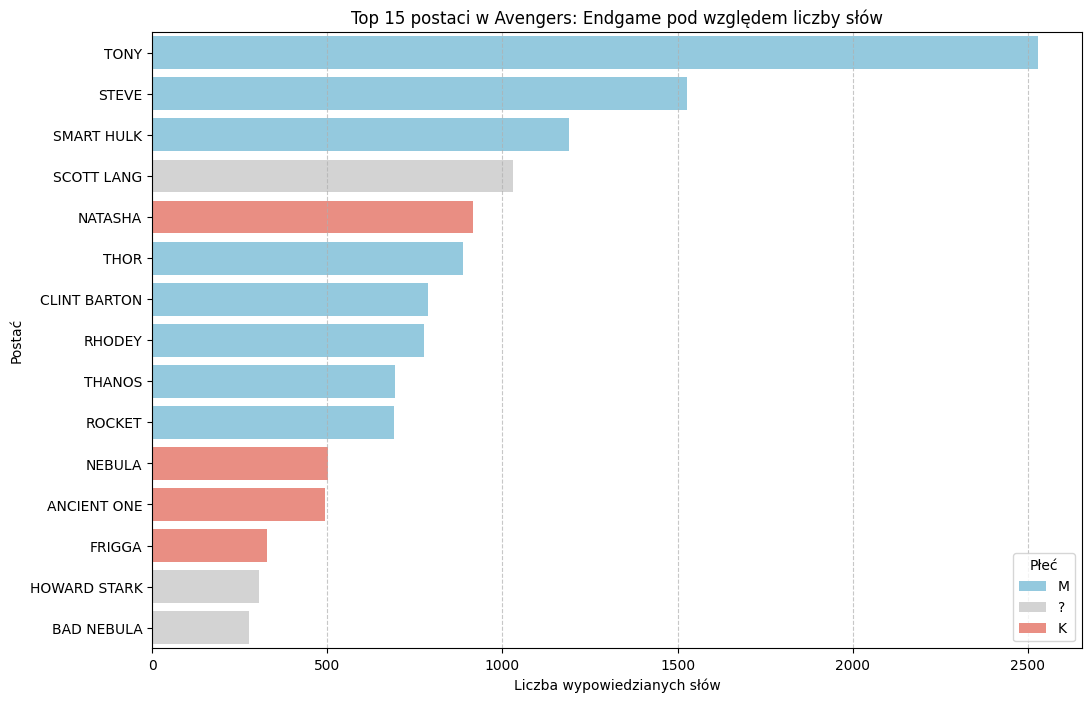


📊 Statystyka reprezentacji:
Udział słów wypowiadanych przez kobiety (K): 17.81%


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Połączenie rankingu ze słownikiem płci
postacie = ranking.copy()
postacie['plec'] = postacie['postac'].map(plec)

# 2. Obliczenie procentu słów kobiet
total_words = postacie['liczba_slow'].sum()
female_words = postacie[postacie['plec'] == 'K']['liczba_slow'].sum()
procent_kobit = (female_words / total_words) * 100

# 3. Przygotowanie danych do wykresu (Top 15)
top_15 = postacie.head(15)

# 4. Rysowanie wykresu
plt.figure(figsize=(12, 8))
colors = {'M': 'skyblue', 'K': 'salmon', '?': 'lightgrey'}
sns.barplot(
    data=top_15,
    x='liczba_slow',
    y='postac',
    hue='plec',
    palette=colors,
    dodge=False
)

plt.title('Top 15 postaci w Avengers: Endgame pod względem liczby słów')
plt.xlabel('Liczba wypowiedzianych słów')
plt.ylabel('Postać')
plt.legend(title='Płeć', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

# 5. Wyświetlenie statystyki pod wykresem
print(f"\n📊 Statystyka reprezentacji:")
print(f"Udział słów wypowiadanych przez kobiety (K): {procent_kobit:.2f}%")

#### Po uruchomieniu powinieneś zobaczyć

- Poziomy wykres postaci kolorowanych płcią, z tytułem i legendą.
- Pod wykresem procent słów wypowiedzianych przez postacie kobiece.

#### Pytanie interpretacyjne

Jaki procent dialogu należy do kobiet? Czy ten film „przeszedłby" intuicyjny test reprezentacji? Pamiętaj o granicy metody: udział w mowie ≠ znaczenie postaci — milczenie też bywa znaczące.

---
## Etap 6/6 — Eksport danych

Zapisujemy dwa pliki wejściowe do następnego notatnika.

In [65]:
# === ETAP 6/6 · EKSPORT DANYCH ===
assert 'postacie' in dir() or ('ranking' in dir() and 'plec' in dir()), \
    "⛔ Najpierw uruchom Etapy 3, 4 i 5 — brakuje danych do eksportu."
print("📍 Etap 6/6 · Eksport. Zapisujemy `dialogi.csv` i `postacie.csv`.")

📍 Etap 6/6 · Eksport. Zapisujemy `dialogi.csv` i `postacie.csv`.


### Krok 6A. Zapis plików `dialogi.csv` i `postacie.csv`

#### Cel i sens analityczny

Rozdzielamy dane na dwa poziomy: kwestie (`dialogi.csv`) i podsumowanie postaci z płcią (`postacie.csv`). Ten podział wystarczy do analizy emocji w kolejnym module.

#### Prompt dla modelu

```text
Kontekst:
Masz tabelę kwestii w `dialogi`, tabelę `postacie` (ranking + płeć z Etapu 5) i słownik `plec`.

Wejście:
Tabela `dialogi` i tabela `postacie`.

Zadanie:
Zapisz dwa pliki CSV. Plik `dialogi.csv`: jeden wiersz na kwestię, kolumny: numer sceny, postać, treść kwestii, liczba słów. Plik `postacie.csv`: jeden wiersz na postać, kolumny: postać, płeć, liczba słów, liczba kwestii, liczba scen. Kodowanie UTF-8. Zachowaj tabelę postaci jako zmienną o nazwie `postacie`.

Pokaż wynik:
- komunikat o zapisaniu obu plików z liczbą wierszy,
- wskazówkę, jak pobrać je z Colab.

Warunek poprawności:
Oba pliki niepuste. Liczba wierszy w `dialogi.csv` = liczba kwestii; w `postacie.csv` = liczba postaci.

Jeśli wystąpi błąd:
Wyjaśnij, którego pliku nie udało się zapisać i dlaczego.

Nie rób już nic więcej.
```

In [66]:
import pandas as pd
import os

# 1. Przygotowanie finalnej tabeli postacie (na wypadek gdyby nie została zapisana wcześniej)
postacie = ranking.copy()
postacie['plec'] = postacie['postac'].map(plec)

# 2. Wybór i kolejność kolumn zgodnie z zadaniem
# dialogi: numer sceny, postać, treść kwestii, liczba słów
# postacie: postać, płeć, liczba słów, liczba kwestii, liczba scen

dialogi_export = dialogi[['numer_sceny', 'postac', 'tresc_kwestii', 'liczba_slow']]
postacie_export = postacie[['postac', 'plec', 'liczba_slow', 'liczba_kwestii', 'liczba_scen']]

# 3. Zapis do plików CSV (UTF-8)
dialogi_export.to_csv('dialogi.csv', index=False, encoding='utf-8')
postacie_export.to_csv('postacie.csv', index=False, encoding='utf-8')

# 4. Weryfikacja i komunikat
if os.path.exists('dialogi.csv') and os.path.exists('postacie.csv'):
    print(f"✅ Pliki zostały zapisane pomyślnie!")
    print(f"- dialogi.csv: {len(dialogi_export)} wierszy (kwestii)")
    print(f"- postacie.csv: {len(postacie_export)} wierszy (postaci)")
    print("\n🏠 Jak pobrać pliki na dysk?")
    print("1. Otwórz panel boczny (ikona folderu po lewej stronie).")
    print("2. Odśwież widok, jeśli nie widzisz plików.")
    print("3. Kliknij prawym przyciskiem myszy na plik i wybierz 'Download' (Pobierz).")
else:
    print("⛔ Błąd: Nie udało się utworzyć plików CSV. Sprawdź uprawnienia do zapisu w katalogu roboczym.")

✅ Pliki zostały zapisane pomyślnie!
- dialogi.csv: 1039 wierszy (kwestii)
- postacie.csv: 51 wierszy (postaci)

🏠 Jak pobrać pliki na dysk?
1. Otwórz panel boczny (ikona folderu po lewej stronie).
2. Odśwież widok, jeśli nie widzisz plików.
3. Kliknij prawym przyciskiem myszy na plik i wybierz 'Download' (Pobierz).


#### Po uruchomieniu powinieneś zobaczyć

- Potwierdzenie zapisania `dialogi.csv` i `postacie.csv` z liczbą wierszy.
- Wskazówkę, jak pobrać pliki z Google Colab.

---
## Co dalej?

- Masz teraz `dialogi.csv` (pojedyncze wypowiedzi) i `postacie.csv` (postacie z płcią i ilością mowy).
- W **NB2** ocenisz emocje każdej kwestii i narysujesz łuk emocjonalny filmu oraz rozkład emocji wg płci.
- W **NB3** połączysz wszystko z siecią w jedną prezentację.
- Jeśli któryś krok zadziałał źle, poproś model o poprawienie tylko tego jednego fragmentu.